# Multi-Dimensional Scaling (MDS)

> 1964년에 제안된 방법으로 거의 사용되지 않으나 `LLE`등을 이해하기 위한 stepping stone으로 사용됨.

Reduces dimensionality while trying to ***preserve the distances between the instances***.

- Unsupervised Learning
- Dimensionality Reduction
- Projection based algorithm but non-linear

# 정성적 설명

원래의 공간에서 모든 data point들 사이의 pairwise distance를 유지하는 manifold를 구함. 

- 모든 pairwise distance를 matrix $D$로 만들고
- 변환된 공간에서도 최대한 pairwise distance가 $D$와 유사하도록 하는 mapping function을 구함.

$$\underset{Y}\argmin \sum_{i<j}(\|\textbf{y}_i-\textbf{y}_j\|^2_2-\sigma_{ij})^2$$

where

- $\sigma_{ij}$ : $\textbf{x}_i$와 $\textbf{x}_j$간의 거리.

Multidiemensional Scaling은 다음의 가정에 기반을 둠.

- 두 data point의 거리가 가깝다는 것은 해당 data point들이 유사하다는 뜻
- 두 data point의 거리가 멀다는 것은 해당 data point들의 유사도가 낮다는 뜻

즉, MDS는 $n$개의 Data sample간의 distance (or proximity, 근접도)를 나타내는 $n \times n$ matrix 를 계산하고, 이를 가장 잘 보존하는 lower dimension에서의 coordinate를 찾아냄.

# 단점

## 모든 pairwise distance를 유지하다 보니 locality에 집중하지 못함.

MDS는 모든 pairwise distance를 유지하려고 하기 때문에 loss function에서도 알 수 있듯이 가까운 거리에서의 차이보다 먼 거리에서의 차이에 보다 큰 영향을 받게 됨.

> 원래 pairwise distance가 10차이가 나던 경우에서 5가 차이가 나는 경우와,
원래 pairwise distnace가 1000차이가 나던 경우에서 5가 차이가 나는 경우가 있다고 할 때,
일반적으로 전자의 5 차이는 매우 큰 에러이고 후자의 5는 작은 에러라고 봐야하지만 
MDS에서는 같은 중요도를 가짐.
> 

특히, 원본 데이터가 high dimensional space에 존재할 경우, 

- 가까운 이웃간의 거리는 의미상으로 중요하지만
- 지나치게 큰 거리를 가지고 있는 데이터 샘플 pair는 큰 의미가 없음.
- 문제는 큰 의미가 없는 두 data sample pair의 거리에 대한 값 자체가 매우 크다는 점임.
- MDS의 loss function에서는 거리의 차가 작아져야하는데, 큰 거리값은 loss function에 큰 영향력을 가짐.
- 즉, 그 거리의 절대적 크기 자체가 값의 크기만큼의 큰 의미를 지니지 못하는 사례가 MDS에서는 많아짐.

구조에 대한 의미를 전혀 가지지 않고 있는 data sample piar간의 거리가 의미가 없음에도 무의미하게 큰 값을 가져 loss function에 큰 영향을 주게 됨.

- 일반적으로 dimensionalily reduction에서 중요한 것은 locality 정보임.
- MDS는 오히려 locality 정보에 큰 가중치를 부여하지 못하는 한계를 가짐.
- MDS는 구조에 대한 정보를 전혀 가지지 않는 무의미한 큰 값을 가지는 pairwise distance에 집중하다보니 더 중요한 가까운 이웃간의 거리를 무시하게 되는 문제점을 가짐.


## Metric space 기반이라 Higher dimensional data에 적합치 않음.

다른 단점은 MDS는 **metric space에 기반**을 두고 있는데,  high dimensional의 경우,

- $\sigma(a,b),\sigma(a,c)$가 가깝더라도 $\sigma(b,c)$가 매우 먼 경우가 많음.
- 이 같은 경우, metric space가 아니게 됨.
- 즉, high dimensional feature의 경우 metric space 가 아닐 확률이 매우 크며,
- metric space가 아니라면, MDS는 적절한 방법이 아니다.

위의 두가지 단점으로 인해, MDS는 High Dimensional Data에 적용하기에는 적절치 못하며 유용성이 떨어진다.

[metric space 에 대한 참고자료](https://blog.naver.com/dongmin9313/221795352664)

# Scikit-Learn에서의 MDS 예제

In [47]:
import sklearn.datasets as ds

X, gt = ds.make_swiss_roll(
    n_samples = 1000,
    noise = 0.2,
    random_state = 23 
)


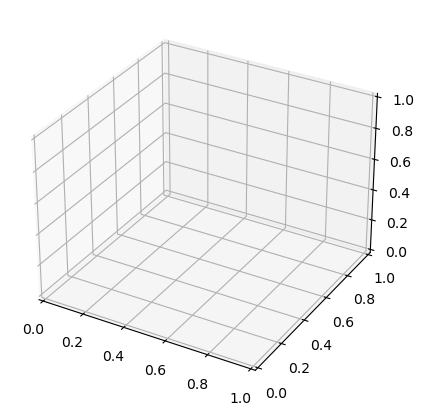

In [48]:

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

fig, axes = plt.subplots(figsize=(5,5), subplot_kw={'projection':'3d'})

In [49]:

def init():
    axes.scatter(X[:,0],X[:,1],X[:,2], c=gt)
    return fig,

def animate(i):
    # axes.scatter(X[:,0],X[:,1],X[:,2], c=gt)
    axes.view_init(elev=10., azim=i*6)
    axes.set_title(f'{i*6}')
    return fig,

anim = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=60,
    interval=200,
    blit=True
)
# anim.save('swiss_roll.gif',fps=30)        

# HTML(anim.to_jshtml())
HTML(anim.to_html5_video())


In [51]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    random_state = 23,
    normalized_stress = 'auto'
)

X_reduced = mds.fit_transform(X)

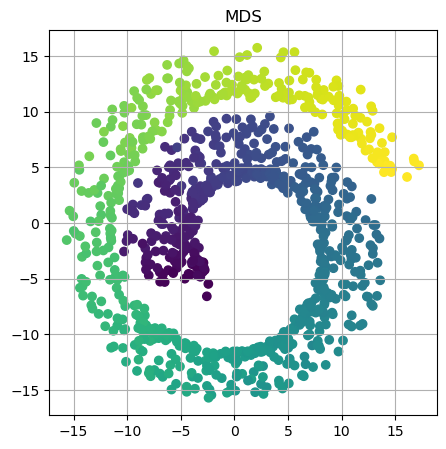

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(5,5))

axes.set_title('MDS')
axes.scatter(X_reduced[:,0], X_reduced[:,1], c=gt)
axes.grid(True)

# 최적 representation

`Scaled-Stress` (or `S-stress`)를 통해 변환된 좌표의 적합성을 측정함.

$$S=\sqrt{\frac{\sum^n_{i=1}\sum^n_{j=i+1}(d_{ij}-\hat{d}_{ij})^2}{\sum^n_{i=1}\sum^n_{j=i+1}(d_{ij})^2}}$$

where,
- $\hat{d}_{ij}$ : MDS로 구한 좌표에서의 거리
- $n$ : # of samples.

$100 \times S$로 구한 값에 따라 다음으로 representation이 잘되었는지를 평가.

| $100 \times S$   | Goodness of fit |
| :---: | :---: |
| \[ 20%,100.0%\] | poor (not worth doing) |
| \[ 10%, 20.0%\) | fair |
| \[  5%, 10.0%\) | good |
| \[2.5%,  5.0%\) | excellent |
| \[  0%,  2.5%\) | perfect |

# References

* [S-Stress](https://imaging.mrc-cbu.cam.ac.uk/statswiki/FAQ/mds/stress)
* [Goodwill, AM, Alison, LJ and Humann M (2009) Multidimensional scaling and the analysis of sexual offence behaviour: a reply to Sturidsson et al. Psychology, Crime & Law 15(6) 517-524.](https://www.tandfonline.com/doi/full/10.1080/10683160802348511?src=recsys&journalCode=gpcl20)
* Dugard P, Todman J and Staines H (2010) Approaching multivariate analysis. A practical introduction. Second Edition. Routledge:New York. This text has example analyses using SPSS.
* Hair Jr, JF, Anderson, RE, Tatham, RL and Black WC (1998) Multivariate data analysis. Fifth Edition. Prentice-Hall:New Jersey.
* Hair Jr, JF, Black, B, Babin, B, Anderson, RE and Tatham, RL (2005) Multivariate data analysis. Sixth Edition. Prentice-Hall:New Jersey. IN CBSU LIBRARY. A 1995 edition is also in the CBSU LIBRARY.